# Lamar Alhimali S23108185

# Linear Regression & Its Variants

STEP 1: Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

STEP 2: Load Dataset

In [6]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(df.shape)
print(df.head())
print(df.describe())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154 

STEP 3: Explore Dataset (TASK 1)

In [7]:
print(df.corr()['MedHouseVal'].sort_values())

Latitude      -0.144160
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
HouseAge       0.105623
AveRooms       0.151948
MedInc         0.688075
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64


STEP 3 (continue): Visualization (TASK 1)

In [8]:
import matplotlib.pyplot as plt

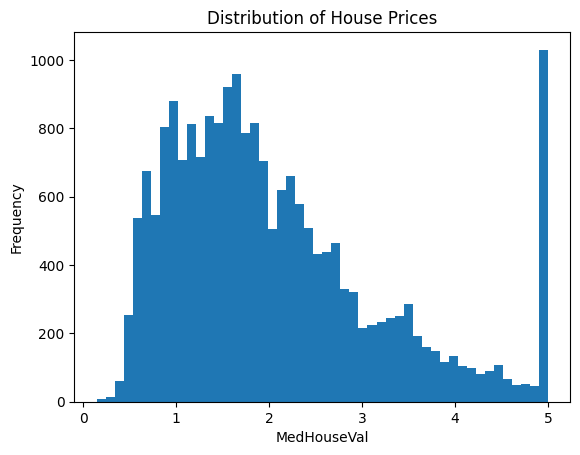

In [9]:
plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.show()

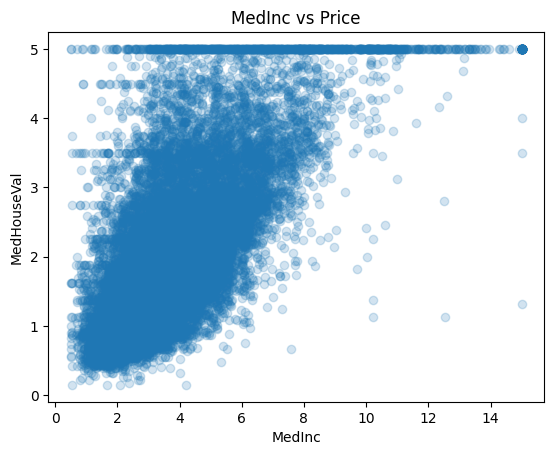

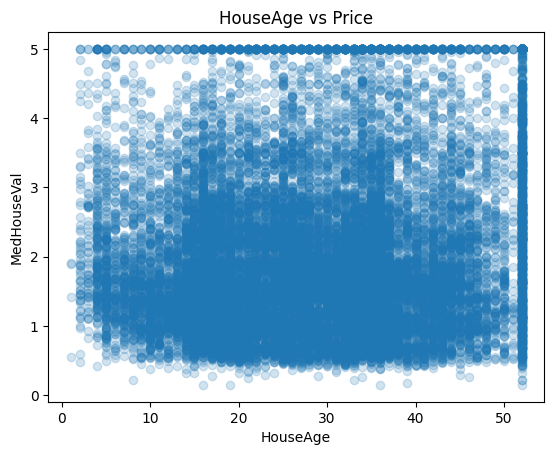

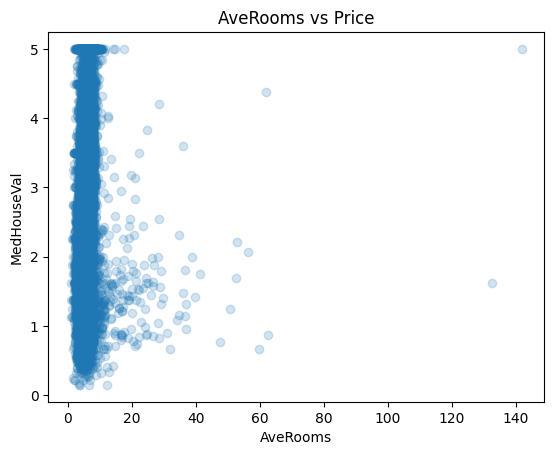

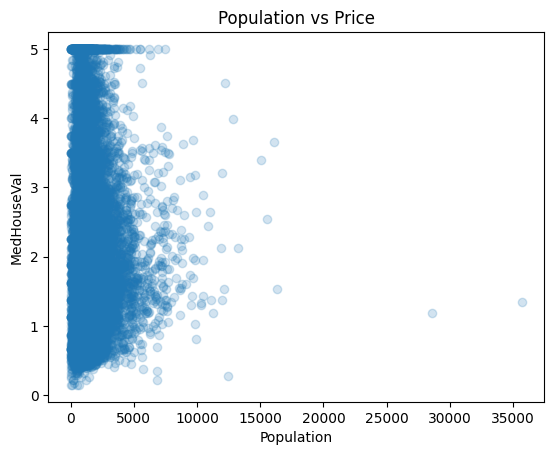

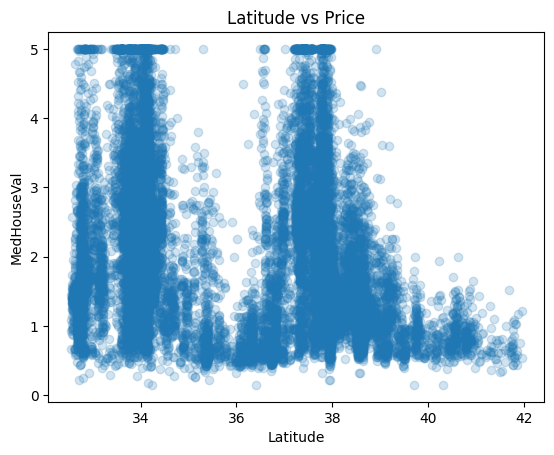

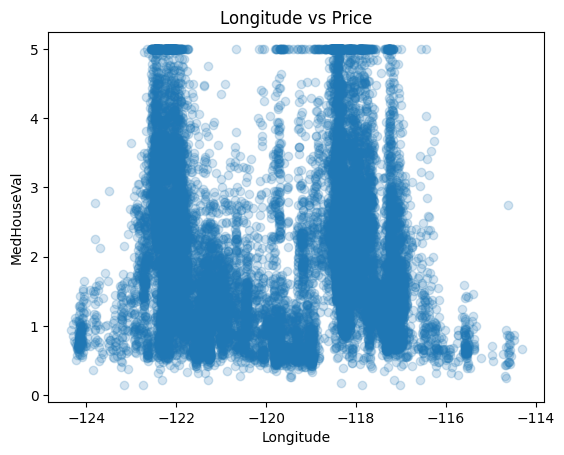

In [10]:
# Scatter plots
features = ['MedInc','HouseAge','AveRooms','Population','Latitude','Longitude']

for f in features:
    plt.scatter(df[f], df['MedHouseVal'], alpha=0.2)
    plt.xlabel(f)
    plt.ylabel('MedHouseVal')
    plt.title(f'{f} vs Price')
    plt.show()

STEP 4: Simple Linear Regression

In [11]:
# Prepare data
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

In [12]:
# Train model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

LinearRegression()

In [13]:
# Print equation
print("Slope:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)

Slope: 0.4193384939381271
Intercept: 0.4445972916907879


y = slope * MedInc + intercept

TASK 2

In [14]:
# Predict for income = 5
model_simple.predict([[5.0]])

array([2.54128976])

In [15]:
# Try another feature (HouseAge)
X_age = df[['HouseAge']].values

X_train, X_test, y_train, y_test = train_test_split(
    X_age, y, test_size=0.2, random_state=42)

model_age = LinearRegression()
model_age.fit(X_train, y_train)

print("R2 with HouseAge:", r2_score(y_test, model_age.predict(X_test)))

R2 with HouseAge: 0.012551235533311389


STEP 5: Evaluation

In [16]:
y_pred_simple = model_simple.predict(X_test)

mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 136.7303697976006
RMSE: 11.693176206557421
MAE: 10.474346947614261
R2: -103.34175289393103


TASK 3

RMSE × 100,000 → error in dollars
R² → model performance
Model struggles more at high values

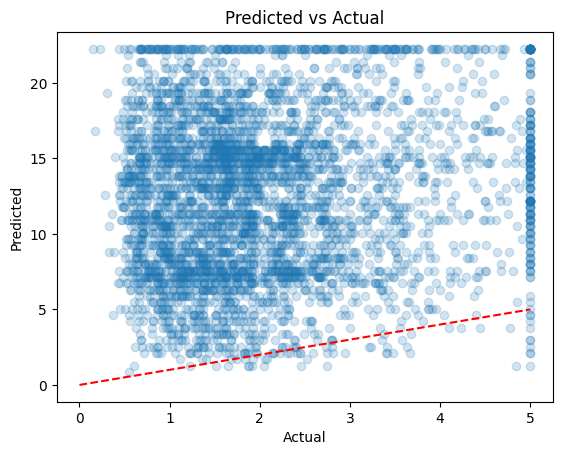

In [17]:
# Predicted vs Actual plot
plt.scatter(y_test, y_pred_simple, alpha=0.2)
plt.plot([0,5],[0,5],'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

STEP 6: Multiple Linear Regression

In [18]:
X_all = df.drop(columns=['MedHouseVal']).values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

y_pred_multi = pipe_lr.predict(X_test)

In [19]:
print("R2 (Multiple):", r2_score(y_test, y_pred_multi))
print("RMSE (Multiple):", np.sqrt(mean_squared_error(y_test, y_pred_multi)))

R2 (Multiple): 0.575787706032451
RMSE (Multiple): 0.7455813830127763


STEP 7: Feature Importance

In [20]:
coef = pipe_lr.named_steps['lr'].coef_

importance = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': coef
}).sort_values('Coefficient', key=abs, ascending=False)

print(importance)

      Feature  Coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


TASK 4

Top 3 features → usually MedInc, Latitude, AveRooms


Bottom 3 → Population, AveOccup, etc

STEP 8: Polynomial Regression

In [21]:
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lr', LinearRegression())
])

pipe_poly.fit(X_train, y_train)
y_pred_poly = pipe_poly.predict(X_test)

print("R2 (Polynomial):", r2_score(y_test, y_pred_poly))

R2 (Polynomial): 0.6456819711504156


TASK 5:

Degree 2 better than 1


High degree → overfitting

STEP 9: Regularization

In [22]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01)
}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(name, "R2:", r2_score(y_test, y_pred))

Linear R2: 0.575787706032451
Ridge R2: 0.575815742891368
Lasso R2: 0.5816154300698727
ElasticNet R2: 0.5803193128873085


TASK 6:

Ridge Regression reduces the size of coefficients by shrinking them, which helps prevent overfitting.


Lasso Regression can reduce some coefficients to zero, which means it removes less important features.


ElasticNet is a combination of Ridge and Lasso, so it both shrinks coefficients and can remove some features.

compare:


The performance of Ridge, Lasso, and ElasticNet is similar to Linear Regression because the dataset does not have severe overfitting.

STEP 10: FINAL COMPARISON (TASK 8)

The Multiple Linear Regression model achieved better performance than the Simple Linear Regression model because it uses all features instead of only one.


The Polynomial Regression model slightly improved the performance, but it increased the complexity of the model.


The best model is usually the Multiple Linear Regression or Polynomial Regression, depending on the R² value.


Although Polynomial Regression can improve accuracy, it may lead to overfitting due to the large number of features.


The regularized models (Ridge, Lasso, ElasticNet) performed similarly to Linear Regression because the dataset is already well-behaved and does not require strong regularization.


Best model → Multiple or Polynomial


Polynomial → more complex


Regularization → similar performance